# Design-Based IPW Confidence Sequences

This notebook shows how to use `delayed_ipw_cs.py` on a dataframe with staggered entry and delayed outcomes.

The example is deliberately set up so treatment affects delayed outcomes along three dimensions:

- a higher probability of ever having a finite-time event,
- a faster event-time distribution among units with finite-time events,
- a lower reward distribution conditional on an event.

The confidence sequence is not for any one of these dimensions separately. It is for their combined effect on cumulative incremental reward as a function of calendar time.

## Input Data

The estimator expects one row per experimental unit with columns:

- `entry_time`: calendar time at which the unit entered the experiment,
- `treatment`: realized treatment assignment,
- `propensity`: probability of treatment assignment, `pi_i(1)`,
- `outcome_time`: observed event time,
- `outcome_value`: observed reward at `outcome_time`.

If a unit is right-censored or never has an event, set `outcome_time` and `outcome_value` to missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from delayed_ipw_cs import ipw_confidence_sequences

## Generate Example Data

This simulation is only for illustration. Treatment increases the probability of observing a finite-time event and makes events arrive sooner, but lowers the reward distribution conditional on an event.

In [2]:
rng = np.random.default_rng(123)
n = 12000

entry_time = np.sort(rng.uniform(0, 30, size=n))
propensity = np.repeat(0.5, n)
treatment = rng.binomial(1, propensity)

# Dimension 1: probability of ever having a finite-time event.
theta_control = 0.70
theta_treatment = 0.85

# Dimension 2: event-time distribution among finite-time events.
# Smaller exponential scale means earlier events on average.
delay_scale_control = 6.0
delay_scale_treatment = 5.0

# Dimension 3: reward distribution conditional on an event.
# Here treatment has lower event-time rewards on average.
reward_mean_control = 1.00
reward_mean_treatment = 0.96

has_finite_event = np.zeros(n, dtype=bool)
for arm, theta in [(0, theta_control), (1, theta_treatment)]:
    arm_idx = np.flatnonzero(treatment == arm)
    n_finite = round(theta * len(arm_idx))
    finite_idx = rng.choice(arm_idx, size=n_finite, replace=False)
    has_finite_event[finite_idx] = True

delay = rng.exponential(
    scale=np.where(treatment == 1, delay_scale_treatment, delay_scale_control),
    size=n,
)
outcome_time = np.where(has_finite_event, entry_time + delay, np.nan)
outcome_value = np.where(
    has_finite_event,
    rng.lognormal(
        mean=np.where(treatment == 1, reward_mean_treatment, reward_mean_control),
        sigma=0.35,
        size=n,
    ),
    np.nan,
)

# Administrative right-censoring at the end of observation.
censor_time = 30.0
observed = has_finite_event & (outcome_time <= censor_time)
outcome_time = np.where(observed, outcome_time, np.nan)
outcome_value = np.where(observed, outcome_value, np.nan)

df = pd.DataFrame(
    {
        "entry_time": entry_time,
        "treatment": treatment,
        "propensity": propensity,
        "outcome_time": outcome_time,
        "outcome_value": outcome_value,
    }
)

df.head()

,entry_time,treatment,propensity,outcome_time,outcome_value
0,0.000652,1,0.5,3.245272,2.903530
1,0.005151,1,0.5,1.033768,3.117605
2,0.005591,1,0.5,0.386336,2.764311
3,0.007929,1,0.5,NaN,NaN
4,0.013993,0,0.5,0.436650,2.880569


## Compute Confidence Sequences

The output has one row per input row, sorted by `entry_time`. The estimates are evaluated at each row's entry time.

In [3]:
cs = ipw_confidence_sequences(df, alpha=0.05, eta2=1.0)

cs.tail()[
    [
        "time",
        "n_entered",
        "control_estimate",
        "treatment_estimate",
        "effect_estimate",
        "effect_lower",
        "effect_upper",
        "p_value",
    ]
]

,time,n_entered,control_estimate,treatment_estimate,effect_estimate,effect_lower,effect_upper,p_value
11995,29.995600,11996,19762.911404,23617.566730,3854.655326,1586.669190,6122.641462,1.261857e-09
11996,29.996129,11997,19762.911404,23617.566730,3854.655326,1586.669190,6122.641462,1.261857e-09
11997,29.996272,11998,19762.911404,23617.566730,3854.655326,1586.669190,6122.641462,1.261857e-09
11998,29.997462,11999,19762.911404,23622.992386,3860.080982,1591.972257,6128.189706,1.173516e-09
11999,29.998463,12000,19769.751047,23622.992386,3853.241339,1584.924227,6121.558451,1.296614e-09


## Plot Confidence Sequences

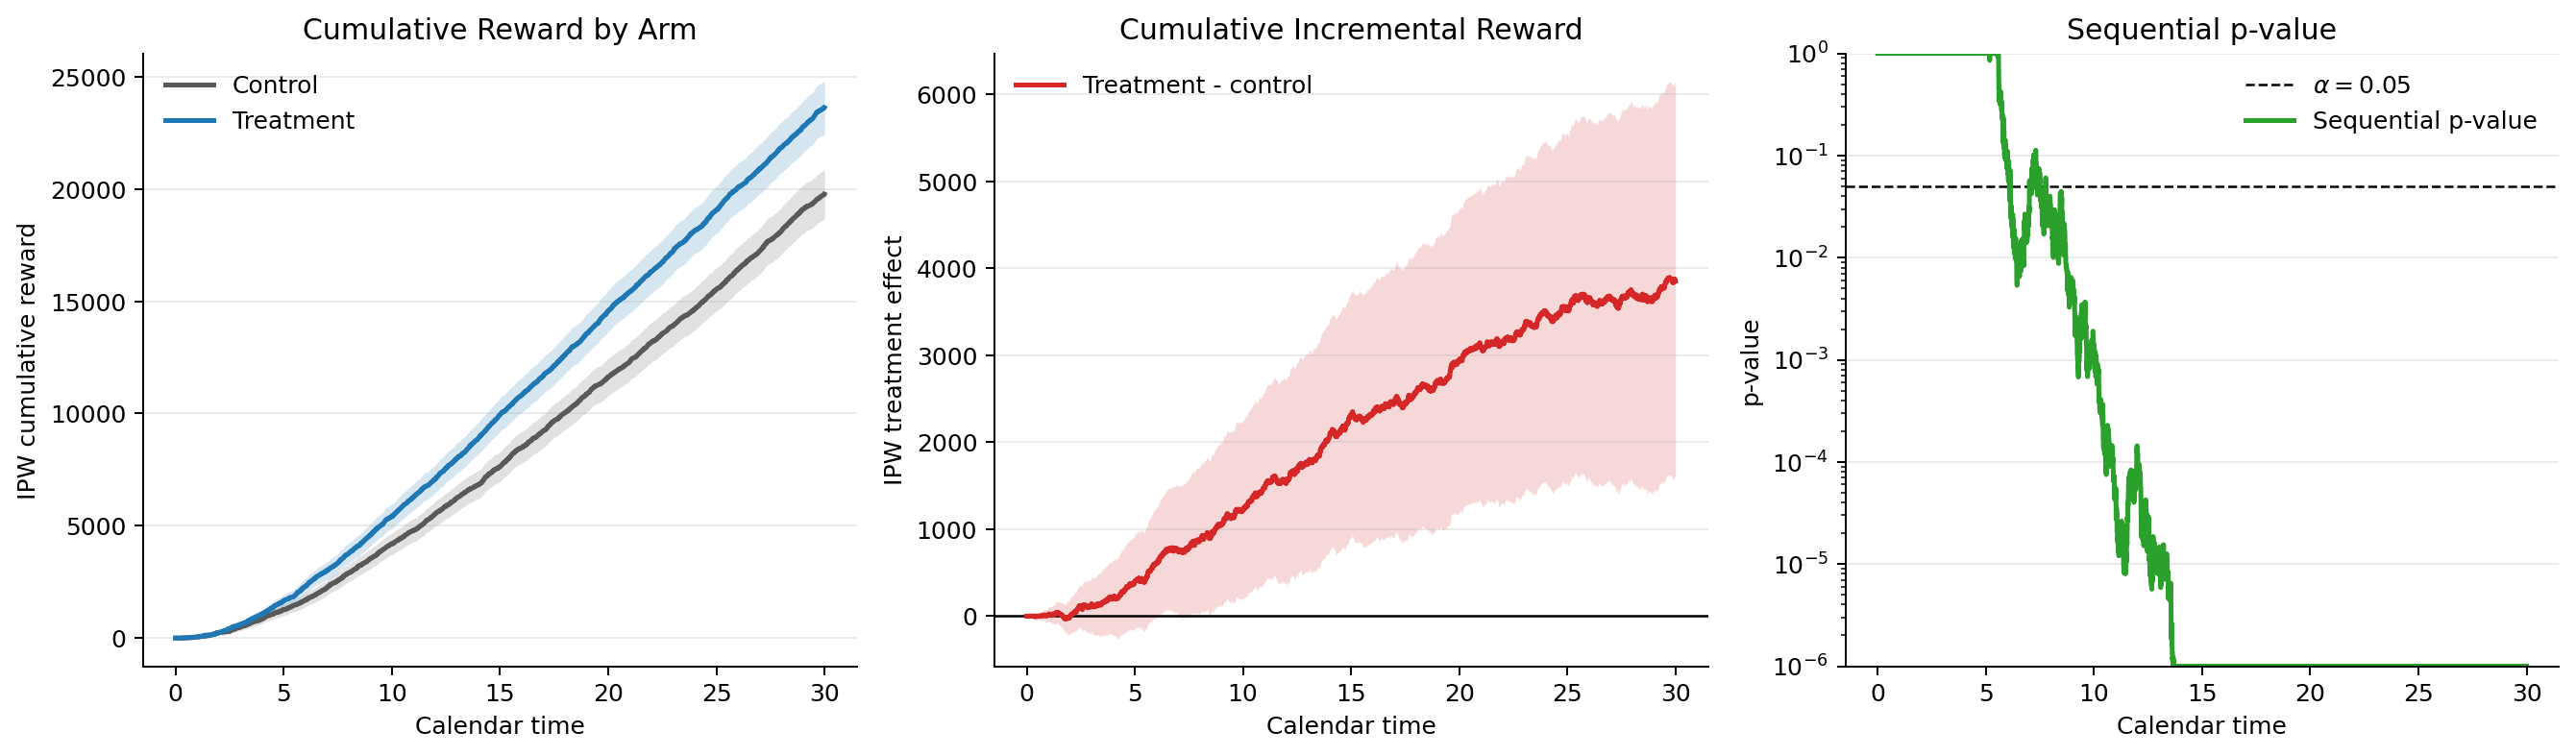

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

x = cs["time"].to_numpy(dtype=float)
p_values = np.clip(cs["p_value"].to_numpy(dtype=float), 1e-6, 1.0)

axes[0].plot(x, cs["control_estimate"], label="Control", color="0.35", linewidth=2)
axes[0].fill_between(
    x,
    cs["control_lower"].to_numpy(dtype=float),
    cs["control_upper"].to_numpy(dtype=float),
    color="0.35",
    alpha=0.18,
    linewidth=0,
)
axes[0].plot(x, cs["treatment_estimate"], label="Treatment", color="C0", linewidth=2)
axes[0].fill_between(
    x,
    cs["treatment_lower"].to_numpy(dtype=float),
    cs["treatment_upper"].to_numpy(dtype=float),
    color="C0",
    alpha=0.18,
    linewidth=0,
)
axes[0].set_title("Cumulative Reward by Arm")
axes[0].set_xlabel("Calendar time")
axes[0].set_ylabel("IPW cumulative reward")
axes[0].legend(frameon=False)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].plot(x, cs["effect_estimate"], label="Treatment - control", color="C3", linewidth=2)
axes[1].fill_between(
    x,
    cs["effect_lower"].to_numpy(dtype=float),
    cs["effect_upper"].to_numpy(dtype=float),
    color="C3",
    alpha=0.18,
    linewidth=0,
)
axes[1].set_title("Cumulative Incremental Reward")
axes[1].set_xlabel("Calendar time")
axes[1].set_ylabel("IPW treatment effect")
axes[1].legend(frameon=False)

axes[2].axhline(0.05, color="black", linestyle="--", linewidth=1, label=r"$\alpha = 0.05$")
axes[2].plot(x, p_values, label="Sequential p-value", color="C2", linewidth=2)
axes[2].set_yscale("log")
axes[2].set_ylim(1e-6, 1.0)
axes[2].set_title("Sequential p-value")
axes[2].set_xlabel("Calendar time")
axes[2].set_ylabel("p-value")
axes[2].legend(frameon=False)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig("figures/confidence_sequences.png", dpi=180, bbox_inches="tight")
plt.show()